# Temporal Split Model

### Setup


In [ ]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import keras
import tensorflow as tf
from keras import layers

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

CONFIG = json.loads((ROOT / "config/project_config.json").read_text())
keras.utils.set_random_seed(CONFIG["seed"])

SEED = CONFIG["seed"]
LABELS = CONFIG["bin_labels"]
CLASSES = np.arange(len(LABELS))
PRIMARY_HORIZON = int(CONFIG["primary_horizon"])
VALIDATION_START_DATE = pd.Timestamp(CONFIG["validation_start_date"])
TEST_START_DATE = pd.Timestamp(CONFIG["test_start_date"])

DATA_PATH = ROOT / f"data/modeling/sfo_delay_features_{PRIMARY_HORIZON}h.parquet"


### Load the Modeling Dataset


In [2]:
df = pd.read_parquet(DATA_PATH)
df = df.loc[df["target_delay_bin"].notna()].copy()
df["flight_date"] = pd.to_datetime(df["flight_date"])
df["target_delay_bin"] = df["target_delay_bin"].astype(int)

overview = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "start_date": [df["flight_date"].min().date()],
        "end_date": [df["flight_date"].max().date()],
    }
)
display(overview)


,rows,columns,start_date,end_date
0,449387,183,2022-01-01,2026-05-31


### Temporal Split


In [3]:
train = df.loc[df["flight_date"] < VALIDATION_START_DATE].copy()
validation = df.loc[
    (df["flight_date"] >= VALIDATION_START_DATE)
    & (df["flight_date"] < TEST_START_DATE)
].copy()
test = df.loc[df["flight_date"] >= TEST_START_DATE].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train), len(validation), len(test)],
        "date_min": [
            train["flight_date"].min().date(),
            validation["flight_date"].min().date(),
            test["flight_date"].min().date(),
        ],
        "date_max": [
            train["flight_date"].max().date(),
            validation["flight_date"].max().date(),
            test["flight_date"].max().date(),
        ],
    }
)
display(split_summary)


,split,rows,date_min,date_max
0,train,293770,2022-01-01,2024-12-31
1,validation,109971,2025-01-01,2025-12-31
2,test,45646,2026-01-01,2026-05-31


### Helper Functions


In [4]:
NON_FEATURES = {
    "flight_id", "flight_date", "fl_date", "scheduled_dep_utc",
    "scheduled_arr_utc", "prediction_cutoff_utc",
    "prediction_horizon_hours", "actual_dep_utc", "actual_arr_utc",
    "dep_delay_minutes", "arr_delay_minutes", "cancelled", "diverted",
    "target_cancelled", "target_delay_ge_15", "target_delay_bin",
    "target_delay_bin_label", "eda_only_carrier_delay_minutes",
    "eda_only_weather_delay_minutes", "eda_only_nas_delay_minutes",
    "eda_only_security_delay_minutes",
    "eda_only_late_aircraft_delay_minutes",
}
FAA_FEATURES = {
    "aircraft_year_manufactured", "aircraft_type_code", "engine_type_code",
    "aircraft_manufacturer", "aircraft_model", "number_of_engines",
    "number_of_seats", "aircraft_weight_class", "aircraft_cruise_speed",
    "engine_thrust", "faa_record_type", "aircraft_age_years",
    "faa_match_flag",
}


def feature_columns(df):
    candidates = [
        column for column in df.columns
        if column not in NON_FEATURES and column not in FAA_FEATURES
    ]
    missing_percent = 100 * df[candidates].isna().mean()
    return [
        column for column in candidates
        if missing_percent[column] < 90
    ]


def split_feature_types(X):
    numeric_features = [
        column for column in X.columns
        if pd.api.types.is_numeric_dtype(X[column])
    ]
    categorical_features = [
        column for column in X.columns
        if column not in numeric_features
    ]
    return numeric_features, categorical_features


def make_xy(df, feature_list):
    X = df[feature_list].copy()
    numeric_features, categorical_features = split_feature_types(X)
    X[numeric_features] = X[numeric_features].apply(pd.to_numeric, errors="coerce")
    for column in categorical_features:
        X[column] = X[column].astype(object).where(X[column].notna(), np.nan)
    y = df["target_delay_bin"].astype(int).to_numpy()
    return X, y


def make_preprocessor(X, dense_output=False):
    numeric_features, categorical_features = split_feature_types(X)

    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=25,
                    sparse_output=not dense_output,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )


def class_weights(y):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=CLASSES,
        y=y,
    )
    return np.sqrt(weights)[y]


def to_float32_dense(matrix):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype="float32")


def build_softmax_baseline(input_width):
    keras.utils.set_random_seed(SEED)
    baseline = keras.Sequential(
        [
            keras.Input(shape=(input_width,)),
            layers.Dense(len(CLASSES), activation="softmax"),
        ],
        name="baseline_softmax_regression",
    )
    baseline.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return baseline


def fit_softmax_baseline(
    X_train,
    y_train,
    X_validation,
    y_validation,
    max_epochs=40,
    batch_size=2048,
):
    baseline = build_softmax_baseline(X_train.shape[1])
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    )
    history = baseline.fit(
        X_train,
        y_train,
        sample_weight=class_weights(y_train),
        validation_data=(
            X_validation,
            y_validation,
            class_weights(y_validation),
        ),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stopping],
    )
    return baseline, history


def score_model(name, split, y_true, probabilities):
    predicted = probabilities.argmax(axis=1)
    return {
        "model": name,
        "split": split,
        "accuracy": accuracy_score(y_true, predicted),
        "macro_f1": f1_score(y_true, predicted, average="macro"),
        "log_loss": log_loss(y_true, probabilities, labels=CLASSES),
    }


### Baseline Model


In [5]:
BASELINE_FEATURES = [
    "reporting_airline",
    "dest",
    "day_of_week",
    "scheduled_dep_hour",
    "scheduled_arr_hour",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "days_until_holiday",
    "days_since_holiday",
    "scheduled_sfo_departures_same_hour",
    "scheduled_carrier_departures_same_hour",
    "distance_miles",
    "scheduled_elapsed_minutes",
]

X_train_base, y_train = make_xy(train, BASELINE_FEATURES)
X_val_base, y_val = make_xy(validation, BASELINE_FEATURES)
X_test_base, y_test = make_xy(test, BASELINE_FEATURES)

baseline_preprocessor = make_preprocessor(X_train_base, dense_output=True)
X_train_base_processed = to_float32_dense(
    baseline_preprocessor.fit_transform(X_train_base)
)
X_val_base_processed = to_float32_dense(
    baseline_preprocessor.transform(X_val_base)
)
X_test_base_processed = to_float32_dense(
    baseline_preprocessor.transform(X_test_base)
)

baseline, baseline_history = fit_softmax_baseline(
    X_train_base_processed,
    y_train,
    X_val_base_processed,
    y_val,
)

baseline_train_prob = baseline.predict(X_train_base_processed, verbose=0)
baseline_val_prob = baseline.predict(X_val_base_processed, verbose=0)
baseline_test_prob = baseline.predict(X_test_base_processed, verbose=0)


### Improved Model


In [6]:
FEATURES = feature_columns(train)

X_train, y_train = make_xy(train, FEATURES)
X_val, y_val = make_xy(validation, FEATURES)
X_test, y_test = make_xy(test, FEATURES)

preprocessor = make_preprocessor(X_train)
X_train_processed = preprocessor.fit_transform(X_train).astype("float32")
X_val_processed = preprocessor.transform(X_val).astype("float32")
X_test_processed = preprocessor.transform(X_test).astype("float32")

xgboost = XGBClassifier(
    objective="multi:softprob",   # Multiclass classification with class probabilities
    num_class=len(CLASSES),       
    n_estimators=180,             
    max_depth=6,                  
    learning_rate=0.06,           
    subsample=0.85,               # Use 85% of training rows for each tree
    colsample_bytree=0.85,        # Use 85% of features for each tree
    min_child_weight=5,          
    reg_lambda=2,                 # L2 regularization to reduce overfitting
    eval_metric="mlogloss",       
    n_jobs=-1,                    
    random_state=CONFIG["seed"],  
)

xgboost.fit(
    X_train_processed,
    y_train,
    sample_weight=class_weights(y_train),
    eval_set=[
        (X_train_processed, y_train),
        (X_val_processed, y_val),
    ],
    verbose=False,
)

xgb_train_prob = xgboost.predict_proba(X_train_processed)
xgb_val_prob = xgboost.predict_proba(X_val_processed)
xgb_test_prob = xgboost.predict_proba(X_test_processed)


### Accuracy Results


In [7]:
results = pd.DataFrame(
    [
        score_model("Baseline logistic", "Train", y_train, baseline_train_prob),
        score_model("Baseline logistic", "Validation", y_val, baseline_val_prob),
        score_model("Baseline logistic", "Test", y_test, baseline_test_prob),
        score_model("XGBoost", "Train", y_train, xgb_train_prob),
        score_model("XGBoost", "Validation", y_val, xgb_val_prob),
        score_model("XGBoost", "Test", y_test, xgb_test_prob),
    ]
)

display(results.pivot(index="model", columns="split", values="accuracy").round(4))
display(results.round(4))


split,Test,Train,Validation
model,,,
Baseline logistic,0.7604,0.7758,0.7942
XGBoost,0.8199,0.8348,0.8390


,model,split,accuracy,macro_f1,log_loss
0,Baseline logistic,Train,0.7758,0.2088,0.8394
1,Baseline logistic,Validation,0.7942,0.2143,0.8210
2,Baseline logistic,Test,0.7604,0.2174,0.8932
3,XGBoost,Train,0.8348,0.6089,0.5659
4,XGBoost,Validation,0.8390,0.4842,0.5741
5,XGBoost,Test,0.8199,0.4983,0.6116


### Log-Loss Curves


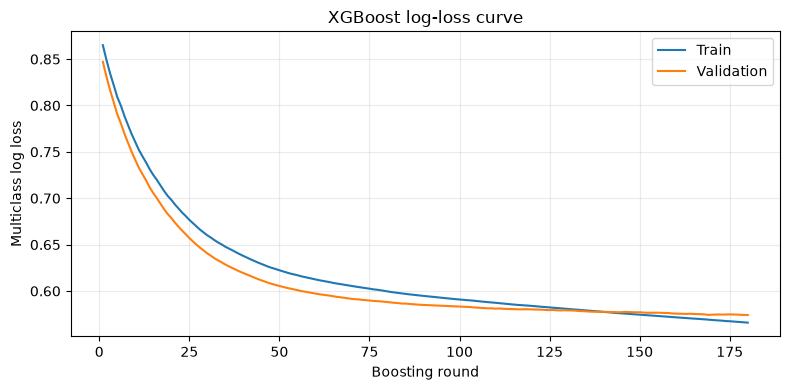

In [8]:
xgb_history = xgboost.evals_result()
xgb_curve = pd.DataFrame(
    {
        "train": xgb_history["validation_0"]["mlogloss"],
        "validation": xgb_history["validation_1"]["mlogloss"],
    }
)
xgb_curve.index = xgb_curve.index + 1
xgb_curve.index.name = "boosting_round"

plt.figure(figsize=(8, 4))
plt.plot(xgb_curve.index, xgb_curve["train"], label="Train")
plt.plot(xgb_curve.index, xgb_curve["validation"], label="Validation")
plt.xlabel("Boosting round")
plt.ylabel("Multiclass log loss")
plt.title("XGBoost log-loss curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Train, Validation, and Test Gap


In [9]:
accuracy_summary = results.pivot(index="model", columns="split", values="accuracy")
accuracy_summary["train_val_gap"] = accuracy_summary["Train"] - accuracy_summary["Validation"]
accuracy_summary["val_test_gap"] = accuracy_summary["Validation"] - accuracy_summary["Test"]

print("Accuracy")
display(accuracy_summary.round(4))

Accuracy


split,Test,Train,Validation,train_val_gap,val_test_gap
model,,,,,
Baseline logistic,0.7604,0.7758,0.7942,-0.0184,0.0338
XGBoost,0.8199,0.8348,0.8390,-0.0042,0.0191


In [10]:
log_loss_summary = results.pivot(index="model", columns="split", values="log_loss")
log_loss_summary["val_test_gap"] = log_loss_summary["Test"] - log_loss_summary["Validation"]

print("Log Loss")
display(log_loss_summary.round(4))

Log Loss


split,Test,Train,Validation,val_test_gap
model,,,,
Baseline logistic,0.8932,0.8394,0.8210,0.0722
XGBoost,0.6116,0.5659,0.5741,0.0375


### Confusion Matrices


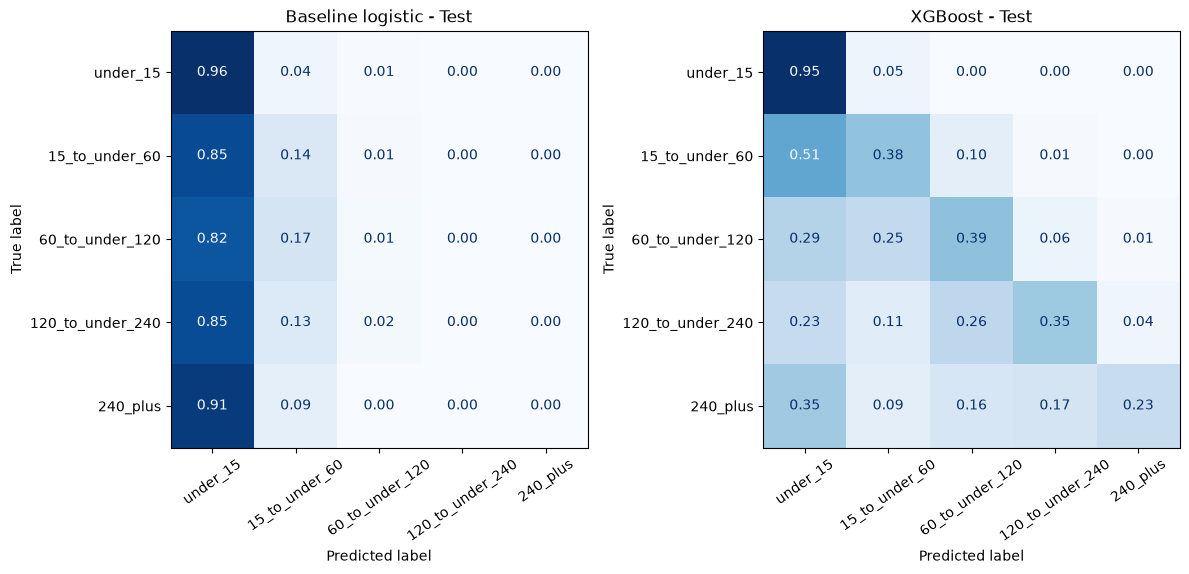

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_test_prob.argmax(axis=1),
    display_labels=LABELS,
    xticks_rotation=35,
    cmap="Blues",
    values_format=".2f",
    normalize="true",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Baseline logistic - Test")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_test_prob.argmax(axis=1),
    display_labels=LABELS,
    xticks_rotation=35,
    cmap="Blues",
    values_format=".2f",
    normalize="true",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("XGBoost - Test")

plt.tight_layout()
plt.show()


The main difference we see between this model and the previous is in the temporal split. Previous iterations utilized an expanding cross validation approach which in the end trained on 2022-2025 data and tested on 2026 data. 

This temporal split method is more simple: training on 2022-2024, validation on 2025, and testing on 2026. 

Despite having less data to train on, the temporal split method still performed well with a very slight drop in accuracy ~ -0.001%